## Importing Libraries and load the txt file

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("chat.txt", header=None, on_bad_lines='skip', encoding='utf8')

In [3]:
df

,0,1
0,‎[26/02/25,9:57:33 PM] K@v!n: Anybody facing slack issue...
1,[26/02/25,9:57:50 PM] Diviya Fleet Team(verizon): Yes
2,[26/02/25,9:58:13 PM] Vignesh Verizon: Myself too for p...
3,[26/02/25,9:58:17 PM] Diviya Fleet Team(verizon): Aske...
4,[26/02/25,9:58:32 PM] Vignesh Verizon: Restarted the la...
...,...,...
704,‎[21/02/26,10:02:42 PM] Karthick Fleet: ‎image omitted
705,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
706,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
707,‎[21/02/26,10:02:44 PM] Karthick Fleet: ‎image omitted


## changig the columns name 

In [4]:
df.columns =['Date','chat']

In [5]:
df

,Date,chat
0,‎[26/02/25,9:57:33 PM] K@v!n: Anybody facing slack issue...
1,[26/02/25,9:57:50 PM] Diviya Fleet Team(verizon): Yes
2,[26/02/25,9:58:13 PM] Vignesh Verizon: Myself too for p...
3,[26/02/25,9:58:17 PM] Diviya Fleet Team(verizon): Aske...
4,[26/02/25,9:58:32 PM] Vignesh Verizon: Restarted the la...
...,...,...
704,‎[21/02/26,10:02:42 PM] Karthick Fleet: ‎image omitted
705,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
706,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
707,‎[21/02/26,10:02:44 PM] Karthick Fleet: ‎image omitted


## Spliting the columns

In [6]:
Message = df['chat'].str.split(']',n=1,expand=True)
df['Time']= Message[0]

In [7]:
df

,Date,chat,Time
0,‎[26/02/25,9:57:33 PM] K@v!n: Anybody facing slack issue...,9:57:33 PM
1,[26/02/25,9:57:50 PM] Diviya Fleet Team(verizon): Yes,9:57:50 PM
2,[26/02/25,9:58:13 PM] Vignesh Verizon: Myself too for p...,9:58:13 PM
3,[26/02/25,9:58:17 PM] Diviya Fleet Team(verizon): Aske...,9:58:17 PM
4,[26/02/25,9:58:32 PM] Vignesh Verizon: Restarted the la...,9:58:32 PM
...,...,...,...
704,‎[21/02/26,10:02:42 PM] Karthick Fleet: ‎image omitted,10:02:42 PM
705,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted,10:02:43 PM
706,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted,10:02:43 PM
707,‎[21/02/26,10:02:44 PM] Karthick Fleet: ‎image omitted,10:02:44 PM


In [8]:
Message1 = Message[1].str.split(':',n=1,expand=True)
df['Name']= Message1[0]
df['chat']= Message1[1]

In [9]:
df

,Date,chat,Time,Name
0,‎[26/02/25,Anybody facing slack issue? For me not able t...,9:57:33 PM,K@v!n
1,[26/02/25,Yes,9:57:50 PM,Diviya Fleet Team(verizon)
2,[26/02/25,Myself too for past twenty 20 minutes,9:58:13 PM,Vignesh Verizon
3,[26/02/25,Asked Deen to post in the channel,9:58:17 PM,Diviya Fleet Team(verizon)
4,[26/02/25,Restarted the laptop too..not working,9:58:32 PM,Vignesh Verizon
...,...,...,...,...
704,‎[21/02/26,‎image omitted,10:02:42 PM,Karthick Fleet
705,‎[21/02/26,‎image omitted,10:02:43 PM,Karthick Fleet
706,‎[21/02/26,‎image omitted,10:02:43 PM,Karthick Fleet
707,‎[21/02/26,‎image omitted,10:02:44 PM,Karthick Fleet


## Ordering the colums

In [10]:
df=df[["Date",'Time','Name','chat']]
df

,Date,Time,Name,chat
0,‎[26/02/25,9:57:33 PM,K@v!n,Anybody facing slack issue? For me not able t...
1,[26/02/25,9:57:50 PM,Diviya Fleet Team(verizon),Yes
2,[26/02/25,9:58:13 PM,Vignesh Verizon,Myself too for past twenty 20 minutes
3,[26/02/25,9:58:17 PM,Diviya Fleet Team(verizon),Asked Deen to post in the channel
4,[26/02/25,9:58:32 PM,Vignesh Verizon,Restarted the laptop too..not working
...,...,...,...,...
704,‎[21/02/26,10:02:42 PM,Karthick Fleet,‎image omitted
705,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted
706,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted
707,‎[21/02/26,10:02:44 PM,Karthick Fleet,‎image omitted


## Sentimental Analysis
### It help to identify the group coversation is postive or negative

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 709 entries, 0 to 708
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    709 non-null    str  
 1   Time    548 non-null    str  
 2   Name    532 non-null    str  
 3   chat    532 non-null    str  
dtypes: str(4)
memory usage: 22.3 KB


In [12]:
#!pip install nltk
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/kavin/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [32]:
##Natural Language Toolkit -nltk

In [13]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [14]:
dataset = df

In [15]:
dataset.dropna(inplace=True)

In [16]:
sid = SentimentIntensityAnalyzer()
senti = sid.polarity_scores(dataset['chat'][4])
senti

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [17]:
senti['compound']

0.0

In [18]:
def sentimentalAnalysis(data,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data

In [19]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='chat')

<Figure size 640x480 with 0 Axes>

In [20]:
data_Senti

,Date,Time,Name,chat,scores,compound,Negtive,Postive,Neutral,comp_score
0,‎[26/02/25,9:57:33 PM,K@v!n,Anybody facing slack issue? For me not able t...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
1,[26/02/25,9:57:50 PM,Diviya Fleet Team(verizon),Yes,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.4019,0.0,1.000,0.000,pos
2,[26/02/25,9:58:13 PM,Vignesh Verizon,Myself too for past twenty 20 minutes,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
3,[26/02/25,9:58:17 PM,Diviya Fleet Team(verizon),Asked Deen to post in the channel,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
4,[26/02/25,9:58:32 PM,Vignesh Verizon,Restarted the laptop too..not working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
...,...,...,...,...,...,...,...,...,...,...
704,‎[21/02/26,10:02:42 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
705,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
706,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
707,‎[21/02/26,10:02:44 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos


In [21]:
pos

,count
comp_score,
pos,515
neg,17


## Topic Modeling ---> Unsupervised Algorithm
### It helps fliter the What topic is mainly or more in the chat conversation

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["chat"])

In [36]:
#Nonnegative -Matrix Factorization
## Split text into hidden patterns --> These words together form a topic

In [34]:
from sklearn.decomposition import NMF  
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)

,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [25]:
for index,topic in enumerate(nmf_model.components_):
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['day', 'jpg', 'make', 'sev', 'document', 'gif', 'sticker', 'diwali', 'omitted', 'image']
['aswathama', 'aswath', 'diwali', 'prince', 'joshva', 'daniel', 'anand', 'verizon', 'birthday', 'happy']
['team', 'armesh', 'added', 'thank', 'hi', 'verizon', 'sure', 'manager', 'vz', 'ullas']
['nagarajan', 'armesh', 'anand', 'vignesh', 'aswathama', 'daniel', 'verizon', 'security', 'code', 'changed']
['contact', 'mp4', 'jpg', 'document', 'gif', 'reasons', 'started', 'sticker', 'omitted', 'video']


In [26]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)

In [27]:
df

,Date,Time,Name,chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
0,‎[26/02/25,9:57:33 PM,K@v!n,Anybody facing slack issue? For me not able t...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,0
1,[26/02/25,9:57:50 PM,Diviya Fleet Team(verizon),Yes,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.4019,0.0,1.000,0.000,pos,2
2,[26/02/25,9:58:13 PM,Vignesh Verizon,Myself too for past twenty 20 minutes,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,2
3,[26/02/25,9:58:17 PM,Diviya Fleet Team(verizon),Asked Deen to post in the channel,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,2
4,[26/02/25,9:58:32 PM,Vignesh Verizon,Restarted the laptop too..not working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,2
...,...,...,...,...,...,...,...,...,...,...,...
704,‎[21/02/26,10:02:42 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,0
705,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,0
706,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,0
707,‎[21/02/26,10:02:44 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,0


In [28]:
df["Topic"].value_counts()

Topic
2    235
0    127
1    107
3     32
4     31
Name: count, dtype: int64

## Wordcloud

In [29]:
#!pip install wordCloud

In [30]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/kavin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

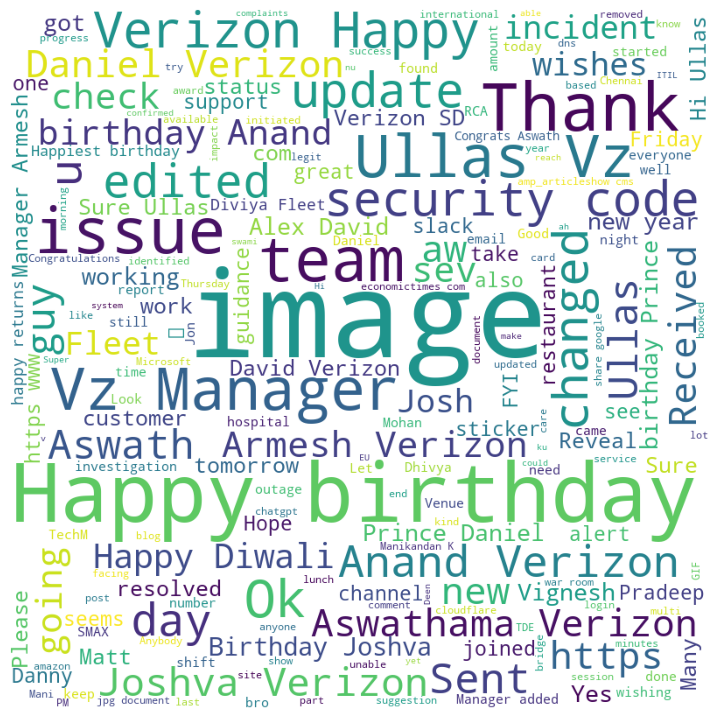

✅ WordCloud created successfully


In [31]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

# Stopwords
stoplist = stopwords.words('english')
stoplist.extend(['omitted','voice','missed','call','video','deleted','media','message'])

# Ensure no NaN and convert to string
text_data = dataset['chat'].dropna().astype(str)

# Combine all text at once (IMPORTANT)
all_text = " ".join(text_data)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stoplist,
    min_font_size=10
).generate(all_text)

# Plot
plt.figure(figsize=(9, 7))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

# Save
plt.savefig('wordcloud.png')
plt.show()

print("✅ WordCloud created successfully")

## Flirt Encounters

In [37]:
flirt_words = [
    'love','miss you','baby','babe','dear','sweet','kiss','hug',
    'cutie','beautiful','handsome','😍','😘','❤️','💕','😚'
]

def detect_flirt(text):
    text = str(text).lower()
    return any(word in text for word in flirt_words)

dataset['flirt'] = dataset['chat'].apply(detect_flirt)

In [38]:
flirt_count = dataset['flirt'].sum()
print("Total Flirt Messages:", flirt_count)

Total Flirt Messages: 4


## Media Encounters

In [43]:
def detect_media(text):
    text = str(text).lower()
    return 'media omitted' in text or '<media omitted>' in text

dataset['media'] = dataset['chat'].apply(detect_media)

In [44]:
media_count = dataset['media'].sum()
print("Total Media Messages:", media_count)

Total Media Messages: 0


In [45]:
print("Total Messages:", len(dataset))
print("Flirt Messages:", dataset['flirt'].sum())
print("Media Messages:", dataset['media'].sum())

Total Messages: 532
Flirt Messages: 4
Media Messages: 0
